# 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Линейная модель (малые углы): T = 2.006 с
2. Нелинейная модель (численно): T = 1.249 с


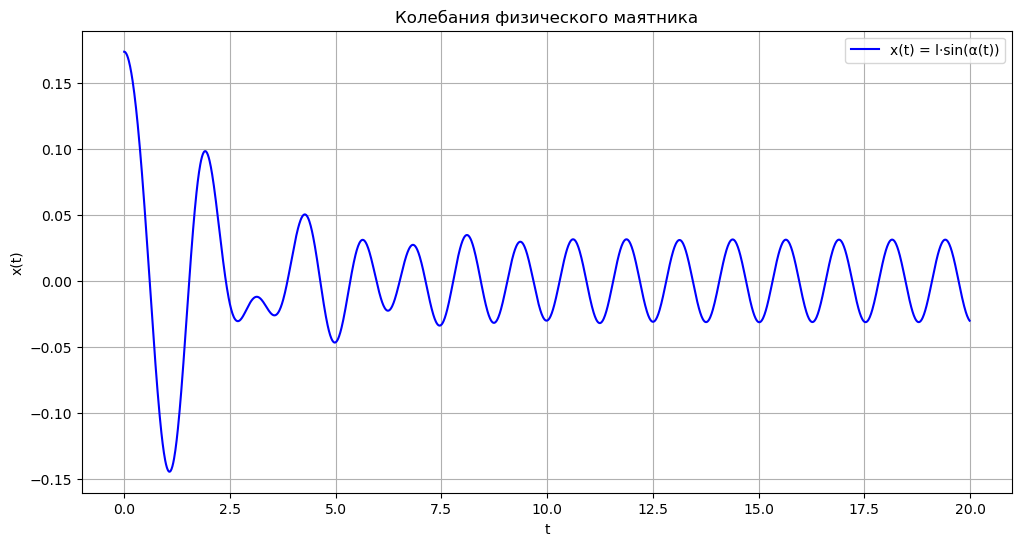

In [18]:
g = 9.81      
l = 1    
gamma = 1  
A0 = 0.5       
omega1 = 5.0  
omega0 = np.sqrt(g / l) 

alpha0 = np.radians(10) 
omega_initial = 0.0   

t_start = 0.0
t_end = 20.0
dt = 0.01  

def derivatives(t, y, omega0, gamma, A0, omega1):
    alpha, omega = y
    dalpha_dt = omega
    domega_dt = -omega0**2 * np.sin(alpha) - gamma * omega + A0 * np.cos(omega1 * t)
    return [dalpha_dt, domega_dt]


def runge_kutta4(t, y, dt, derivatives, *args):
    k1 = derivatives(t, y, *args)
    k2 = derivatives(t + dt/2, [y[i] + dt/2 * k1[i] for i in range(len(y))], *args)
    k3 = derivatives(t + dt/2, [y[i] + dt/2 * k2[i] for i in range(len(y))], *args)
    k4 = derivatives(t + dt, [y[i] + dt * k3[i] for i in range(len(y))], *args)
    
    y_new = [
        y[i] + dt/6 * (k1[i] + 2*k2[i] + 2*k3[i] + k4[i]) 
        for i in range(len(y))
    ]
    return y_new

time = np.arange(t_start, t_end, dt)
alpha = np.zeros_like(time)
omega = np.zeros_like(time)

y = [alpha0, omega_initial]
alpha[0] = alpha0
omega[0] = omega_initial

for i in range(1, len(time)):
    y = runge_kutta4(time[i-1], y, dt, derivatives, omega0, gamma, A0, omega1)
    alpha[i] = y[0]
    omega[i] = y[1]

x = l * np.sin(alpha)

def find_period(time, signal):
    peaks = np.where((signal[1:-1] > signal[:-2]) & (signal[1:-1] > signal[2:]))[0] + 1
    if len(peaks) < 2:
        return np.nan
    periods = np.diff(time[peaks])
    return np.mean(periods)

T_nonlinear = find_period(time, x)

T_linear = 2 * np.pi / omega0

print(f"1. Линейная модель (малые углы): T = {T_linear:.3f} с")
print(f"2. Нелинейная модель (численно): T = {T_nonlinear:.3f} с")

plt.figure(figsize=(12, 6))
plt.plot(time, x, label='x(t) = l·sin(α(t))', color='blue')
plt.title('Колебания физического маятника')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.legend()
plt.show()

# 2

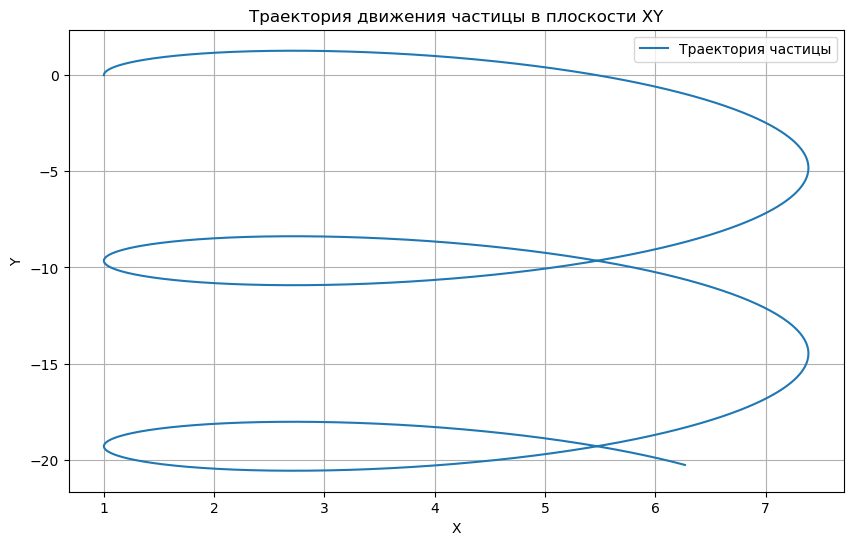

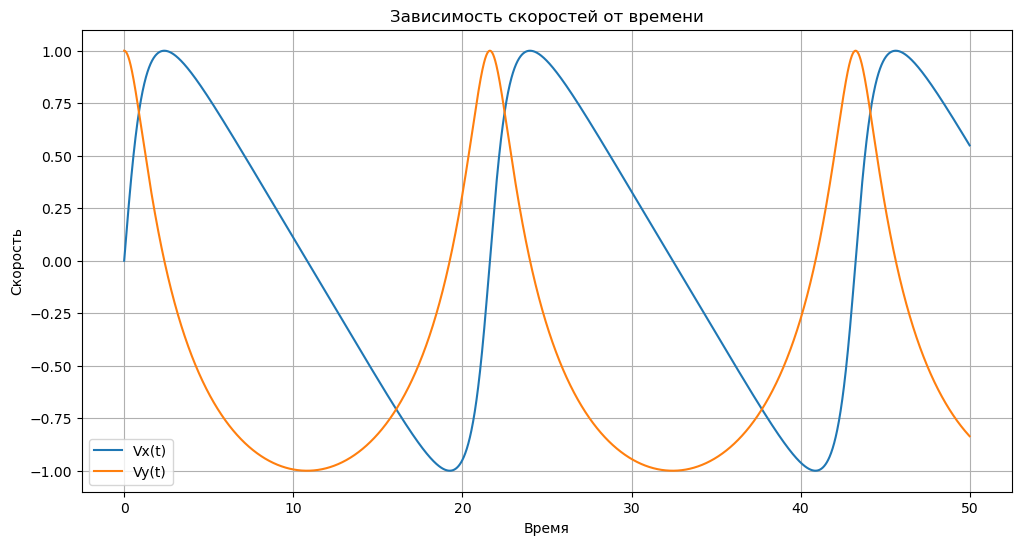

In [28]:
# безразмерные
J = 1.0          
v0 = 1.0       
r0 = 1.0        
tau0 = 1.0      

def derivatives(t, y):
    x_prime, y_prime, vx_prime, vy_prime = y
    dxdt = vx_prime
    dydt = vy_prime
    dvxdt = vy_prime / x_prime
    dvydt = -vx_prime / x_prime
    return [dxdt, dydt, dvxdt, dvydt]

def runge_kutta4(t, y, dt, derivatives):
    k1 = derivatives(t, y)
    k2 = derivatives(t + dt/2, [y[i] + dt/2 * k1[i] for i in range(4)])
    k3 = derivatives(t + dt/2, [y[i] + dt/2 * k2[i] for i in range(4)])
    k4 = derivatives(t + dt, [y[i] + dt * k3[i] for i in range(4)])
    return [y[i] + dt/6*(k1[i] + 2*k2[i] + 2*k3[i] + k4[i]) for i in range(4)]

y0 = [1.0, 0.0, 0.0, 1.0]  

t_start = 0.0
t_end = 50.0  
dt = 0.01    
time = np.arange(t_start, t_end, dt)
solution = np.zeros((len(time), 4))
solution[0] = y0

for i in range(1, len(time)):
    solution[i] = runge_kutta4(time[i-1], solution[i-1], dt, derivatives)

x_prime = solution[:, 0]
y_prime = solution[:, 1]
vx_prime = solution[:, 2]
vy_prime = solution[:, 3]

x = x_prime * r0
y = y_prime * r0
vx = vx_prime * v0
vy = vy_prime * v0

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Траектория частицы')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Траектория движения частицы в плоскости XY')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time, vx, label='Vx(t)')
plt.plot(time, vy, label='Vy(t)')
plt.xlabel('Время')
plt.ylabel('Скорость')
plt.title('Зависимость скоростей от времени')
plt.grid(True)
plt.legend()
plt.show()